In [1]:
import sys
import os
import pandas as pd

# Aggiunge la cartella padre (project/) al PYTHONPATH
sys.path.append(os.path.abspath(".."))

import backtester.metrics as metrics
import backtester.engine as engine
import data.loader as loader
from strategies.moving_average import MovingAverageStrategy


# print(os.getcwd())


Date
2010-03-02    1000.000000
2010-03-03    1000.000000
2010-03-04    1000.000000
2010-03-05    1000.000000
2010-03-08    1000.000000
                 ...     
2020-02-24    4077.565419
2020-02-25    4077.565419
2020-02-26    4077.565419
2020-02-27    4077.565419
2020-02-28    4077.565419
Name: equity_curve, Length: 2517, dtype: float64
3.0775654190910027


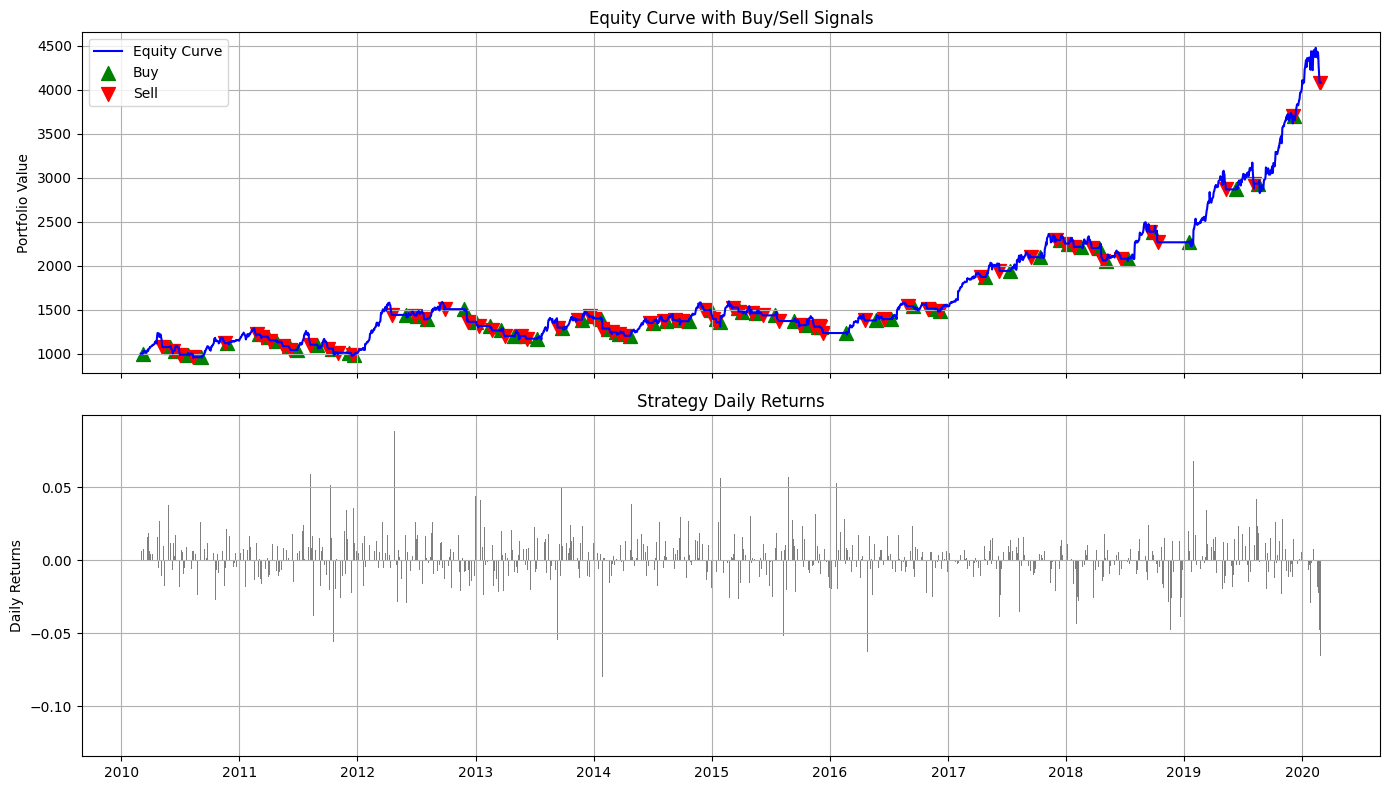

=== Backtest Metrics ===
total_return: 3.0776
max_drawdown: -0.2673
sharpe_ratio: 0.87


In [ ]:
data = loader.load_csv("data/AAPL.csv")

closing_prices = data["close"]

ma_strategy = MovingAverageStrategy(short_window=5, long_window=20)
ma_signals = ma_strategy.generate_signals(closing_prices)

backtest = engine.run_backtest(closing_prices, ma_signals, 1000)

strategy_metrics = metrics.compute_metrics(backtest["equity_curve"], backtest["returns"], 0.03)

metrics.plot_backtest_with_signals(backtest["equity_curve"], backtest["returns"], ma_signals, strategy_metrics)
